In [ ]:
#https://www.kaggle.com/datasets/arnavkulkarni/housing-prices-in-london
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
#imported all necessary libraries for this Regression model

In [ ]:
#Uploading the correct file for the algorithm into google colab
from google.colab import files
uploaded=files.upload()
df=pd.read_csv('London.csv')
df.head()

Saving London.csv to London.csv


,Unnamed: 0,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code
0,0,Queens Road,1675000,House,2716,5,5,5,Wimbledon,London,SW19 8NY
1,1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA
2,2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL
3,3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP
4,4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL


In [ ]:
df.rename(columns={"City/County": "City"}, inplace=True)
#Renaming one of the columns as City instead of "City/County".
#The system could not recognize the "/" so the code would fail

In [ ]:
df.drop('Unnamed: 0', axis=1, inplace=True)# dropping the unnamed column because we have no used for it

In [ ]:
#We also dropped these columns as they would not matter for the predicted outcome
#We have enough information to determine the predicted price(s)
df.drop('Property Name', axis=1, inplace=True )
df.drop('Postal Code', axis=1, inplace=True)

In [ ]:
df.head() # Making sure the table looks correct and all columns were dropped correctly

,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City
0,1675000,House,2716,5,5,5,Wimbledon,London
1,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London
2,735000,Flat / Apartment,761,2,2,2,Putney,London
3,1765000,House,1986,4,4,4,Putney,London
4,675000,Flat / Apartment,700,2,2,2,Putney,London


In [ ]:
df= df.dropna(subset=['Location']) #I needed to drop the NA columns from the location columns
df

,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City
0,1675000,House,2716,5,5,5,Wimbledon,London
1,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London
2,735000,Flat / Apartment,761,2,2,2,Putney,London
3,1765000,House,1986,4,4,4,Putney,London
4,675000,Flat / Apartment,700,2,2,2,Putney,London
...,...,...,...,...,...,...,...,...
3473,19950000,Flat / Apartment,3698,5,5,5,Mayfair,London
3476,5275000,Flat / Apartment,1749,3,3,3,St James's,London
3477,5995000,House,4435,6,6,6,Hampstead Garden Suburb,London
3478,6300000,New development,1506,3,3,3,Mayfair,London


In [ ]:
df.isnull().sum() #We doubled checked to see if the columns contained anymore NA columns

,0
Price,0
House Type,0
Area in sq ft,0
No. of Bedrooms,0
No. of Bathrooms,0
No. of Receptions,0
Location,0
City,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['House Type'] = le.fit_transform(df['House Type'])

df['Location'] = le.fit_transform(df['Location'])

df['City'] =le.fit_transform(df['City'])
#We used the label encoder for these columns as they contained strings
#We need to convert to integers in order to determine the prediction price(s)

In [ ]:
df.head() #Double checking the table to see if the label encoder has worked

,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City
0,1675000,3,2716,5,5,5,650,20
1,650000,2,814,2,2,2,384,20
2,735000,2,761,2,2,2,558,20
3,1765000,3,1986,4,4,4,558,20
4,675000,2,700,2,2,2,558,20


In [ ]:
df= df[df['Price'] > 100000] #This gets rid of any house that were listed under $100,000 so it limit it and make it more realistic
df

,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City
0,1675000,3,2716,5,5,5,650,20
1,650000,2,814,2,2,2,384,20
2,735000,2,761,2,2,2,558,20
3,1765000,3,1986,4,4,4,558,20
4,675000,2,700,2,2,2,558,20
...,...,...,...,...,...,...,...,...
3473,19950000,2,3698,5,5,5,515,20
3476,5275000,2,1749,3,3,3,592,20
3477,5995000,3,4435,6,6,6,452,20
3478,6300000,5,1506,3,3,3,515,20


In [ ]:
X = df[['House Type', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions', 'Location', 'City']]
y = df['Price']
#Setting the X variable towards the independent variables of the houses
#Setting the Y variable towards the actual price or predicted price

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30) #This code splits the data into different training and testing sets

model = LinearRegression() #This starts and trains a linear regression model
model.fit(x_train, y_train)

y_pred = model.predict(x_test) #We are making predictions with this test set

mse = mean_squared_error(y_test, y_pred) #This evaluates the model with a MSE and R2 score
r2 = r2_score(y_test, y_pred) #We fixed the test size and random state to get the best mse and r2 score possible

print(f"Mean Squared Error: {mse}") #This prints the outcome of both Mse and r2
print(f'R-Squared: {r2}')


Mean Squared Error: 1425211270484.704
R-Squared: 0.6280299167593716


In [ ]:
def get_prediction(): #We will have the user enter data to predict a house price
#This data includes entering the type of house, the location and city, the sqft, # of bedrooms, and # of bathrooms.
#The if statements make sure the user is inputting a positive or correct number
    while True:
        try:
            HouseType = int(input("Enter the House Type Number: "))
            if HouseType < 0:
                print("Please enter a non_negative number.")
                continue
            Areainsqft = int(input("Enter the square footage: "))
            if Areainsqft <= 0:
                print("Please enter a postive sqft.")
                continue
            NoofBedrooms = int(input("Please enter the number of Bedrooms: "))
            if NoofBedrooms <=0:
                print("Please enter a postive number.")
                continue
            NoofBathrooms = int(input("Please enter the number of Bathrooms: "))
            if NoofBathrooms <=0:
                print("Please enter a postive number.")
                continue
            NoofReceptions = int(input("Please enter the number of Receptions: "))
            if NoofReceptions <= 0:
              print("Please enter a postive number.")
              continue
            Location = int(input("Please enter a location number: "))
            if Location <=0:
              print("Please enter a postive number.")
              continue
            City = int(input("Please enter a City/County number:"))
            if City <= 0:
                print("Please enter a positive number.")
            #This created the input array for all the independent variables or X
            input_data = np.array([[HouseType, Areainsqft, NoofBedrooms, NoofBathrooms, NoofReceptions, Location, City]])
            #This makes the overall prediction from your choices
            predicted_price = model.predict(input_data)[0]
            #This prints out the predicted price
            print(f"The Predicted Price: ${predicted_price:.2f}")
            break
        #The except statement restates if a variable or value is correct
        #It will redirect the user or tell them to retry the prediction.
        except ValueError:
            print("Invalid input. Please enter a valid integer for X.")
        except Exception as e:
            print(f"An error occurred: {e}")
            print("Please reenter the correct values.")
            break
while True: #After you finish it will give you the option to predict another price
    get_prediction()
    another_prediction = input("Do you want to predict another price? (Yes/No): ")
    if another_prediction.lower() != 'yes':
        break



Enter the House Type Number: 5
Enter the square footage: 3000
Please enter the number of Bedrooms: 2
Please enter the number of Bathrooms: 2
Please enter the number of Receptions: 3
Please enter a location number: 515
Please enter a City/County number:20


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The Predicted Price: $4135585.74
Do you want to predict another price? (Yes/No): no


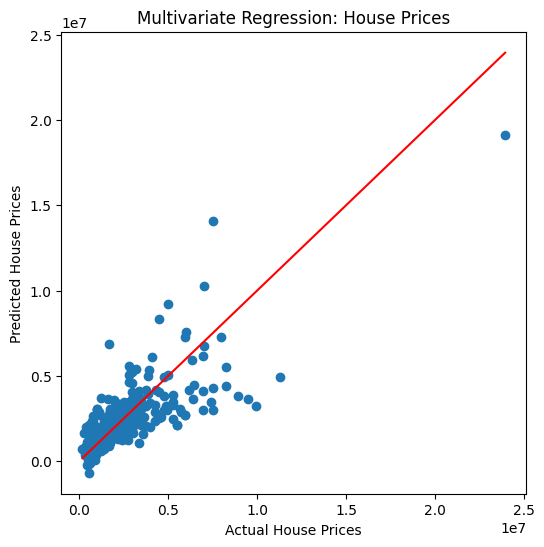

In [ ]:
#This puts the testing sets and puts them in a scatter plot setting the min and max limit
#The X label sets the actual house prices and the y label sets predicted house prices
y_pred = model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Multivariate Regression: House Prices")
plt.show()

In [ ]:
#The only feature engineering that we did not do is the one-hot encoding and normalization because it did not require it for this algorithm and dataset.

Me and my partner decided to use this datasets that has a list of houses based in London. It has the house types and information for where the house is located, number of rooms, sqft etc. We wanted to predict some of the prices from the stated actual prices. Based on information given, the system will giev you a predicted price on the desired sqft, number of bedroom, and in a certain location. It will give you the most acurate price it can based on the prices in London. We also turned it into a graph to show the actual house prices which is the red line and the predicted house prices which are the blue dots labeled on the graph. To clarify this is a multivariate regression model where we used multiple different inputs to determine a certain outcome which in this is the house price. In this case, the predicted prices are not as spread out as we thought, there are more cluttered in one area so the prices are all in similar ranges. If this was based off one input or variable than most likely the dots would follow the line more accurately.